# Load and Plot SWOT EXPERT Data over PACE Data

Authors: Lexi Jones-Kellett, Sarah Lang, Tasha Snow

Please check that SWOT data looks good in SWOT_velocities_maps

- Overlaid streamlines on PACE derived variables (chl-a, pico, syn, pro)

In [1]:
import earthaccess,csv
import xarray as xr
from xarray.backends.api import open_datatree
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
from scipy.ndimage import generic_filter
from scipy.ndimage import gaussian_filter
from scipy.interpolate import griddata
import netCDF4 as nc

#%matplotlib widget # magic matplotlib (if you want that)

In [2]:
# Set default fontsizes for plots
fontsize = 18

plt.rc('font', size=fontsize)          # controls default text sizes
plt.rc('axes', titlesize=fontsize)     # fontsize of the axes title
plt.rc('axes', labelsize=fontsize)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=fontsize)    # fontsize of the tick labels
plt.rc('ytick', labelsize=fontsize)    # fontsize of the tick labels
plt.rc('legend', fontsize=fontsize)    # legend fontsize
plt.rc('figure', titlesize=fontsize)  # fontsize of the figure title

### To do: Below, add date requested in following formats. Input correct AVISO data for eddy of interest. Input correct MOANA file

In [3]:
date_requested = '20240508'
pacedate="2024-05-08"

In [4]:
aviso_ds = xr.open_dataset('data/eddy_trajectories/Edward_Eddy_trajectory_nrt_3.2exp_cyclonic_20180101_20240723.nc')

In [6]:
moana_ds = xr.open_dataset('data/moana/moana_Edward_05082024.nc') # should rename this with file extention .nc
mlon = moana_ds.variables['longitude'] 
mlat = moana_ds.variables['latitude'] 
pro = moana_ds.variables['prococcus_moana']
pico = moana_ds.variables['picoeuk_moana'] 
syn = moana_ds.variables['syncoccus_moana'] 

In [7]:
dates = [i for i in aviso_ds.time.values] # these are sorted already
print(min(dates))
print(max(dates)) # still existed at the end of the dataset
tminny=str(min(dates))
tminny=tminny[0:10]
tmaxxy=str(max(dates))
tmaxxy=tmaxxy[0:10]
tmin,tmax = tminny,tmaxxy
center_lats = [i for i in aviso_ds.latitude.values]
center_lons = [i for i in aviso_ds.longitude.values]
print(len(center_lats))
print(min(center_lats))
print(max(center_lats))
print(min(center_lons)-360)
print(max(center_lons)-360)
#Define box based on eddy
latmin,latmax = min(center_lats)-2,max(center_lats)+2
lonmin,lonmax = min(center_lons)-360-2,max(center_lons)-360+2

2023-12-14T00:00:00.000000000
2024-07-23T00:00:00.000000000
223
35.502697
36.847385
-71.77410888671875
-67.88714599609375


Log into earthaccess

In [8]:
auth = earthaccess.login(persist=True)

Check the names of the SWOT datasets available on earthaccess

In [9]:
def get_swot_data(latmin,latmax,lonmin,lonmax,tmin,tmax):
    """
    Searches for SWOT data within the bounding box and time. Note that this doesn't work for unsmoothed data. 
    
    latmin,latmax: latitude bounds, degrees N (south is negative); floats
    lonmin, lonmax: longitude bounds, degrees E (west is negative); floats
    tmin,tmax: temporal bounds; strings of form 'yyyy-mm-dd'
    """
    bbox = (lonmin, latmin, lonmax, latmax) # lonW, latS, lonE, latN
    results = earthaccess.search_data(
        short_name="SWOT_L2_LR_SSH_EXPERT_2.0",
        bounding_box=bbox,
        temporal=(tmin,tmax))
    
    print("Number of swaths: " + str(len(results))) # not daily files, so will likely be more than # of days
    paths = earthaccess.open(results) # is there a way to choose a subset of variables here?

    return paths

In [10]:
eddy_paths = get_swot_data(latmin,latmax,lonmin,lonmax,tmin,tmax)

Number of swaths: 242


QUEUEING TASKS | :   0%|          | 0/242 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/242 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/242 [00:00<?, ?it/s]

Get all dates with SWOT swaths through the bounding box

In [ ]:
# dates_available = []
# for i in eddy_paths:
#     today = str(i).split('-')[-1].split('_')[-4][0:8]
#     if today not in dates_available:
#         dates_available.append(today)
# # print(dates_available)

Get data from a specific date

NOTE: 2024/05/23 isn't cropping

In [11]:
ind = 0 
for i in eddy_paths:
    today = str(i).split('-')[-1].split('_')[-4][0:8]
    if date_requested == today:
        print(ind)
        sel=ind
    ind += 1

166
167


There are 2 swaths on the date of interest

Open a single dataset.

NOTE: Will need to point to different indices if you change the bounding box

In [12]:
ds1 = xr.open_dataset(eddy_paths[sel])
ds2 = xr.open_dataset(eddy_paths[sel-1])

In [13]:
def crop_dataset_by_lat_lon(ds,latmin,latmax,lonmin,lonmax):
    mask = (ds.latitude >= latmin) & (ds.latitude <= latmax) & (ds.longitude >= lonmin+360) & (ds.longitude <= lonmax+360)
    ds_masked = ds.where(mask, drop=True)
    return ds_masked

In [14]:
ds1_masked = crop_dataset_by_lat_lon(ds1,latmin,latmax,lonmin,lonmax)
ds2_masked = crop_dataset_by_lat_lon(ds2,latmin,latmax,lonmin,lonmax)

Need to add 'height_cor_xover' values to ssh & sla variabiles

Regrid SWOT data to regular grid. Need to do this before taking spatial gradients for velocity calculations.

In [15]:
xv = np.arange(lonmin+360, lonmax+360, 0.036)
yv = np.arange(latmin,latmax, 0.036)
grid_x, grid_y = np.meshgrid(xv, yv)
ssh=ds1_masked.ssha_karin_2+ds1_masked.height_cor_xover
lat=ds1_masked.latitude
lon=ds1_masked.longitude
grid_ssh1 = griddata((lon.values.ravel(),lat.values.ravel()), ssh.values.ravel(), (grid_x, grid_y), method='linear')
ssh=ds2_masked.ssha_karin_2+ds2_masked.height_cor_xover
lat=ds2_masked.latitude
lon=ds2_masked.longitude
grid_ssh2 = griddata((lon.values.ravel(),lat.values.ravel()), ssh.values.ravel(), (grid_x, grid_y), method='linear')

Plot regridded SSH

In [16]:
def compute_geos_current(ssh,lat):
    """
    ssh: (m) Make sure this is first corrected with height_cor_xover from L2 data! 
    lat: degrees N
    """
    
    omega = 7.2921159e-05  # angular velocity of the Earth [rad/s]
    fc = 2*omega*np.sin(lat*np.pi/180.)
        
    # avoid zero near equator, bound fc by min val as 1.e-8
    f_coriolis = np.sign(fc)*np.maximum(np.abs(fc), 1.e-8)
    
    dx,dy = 4000,4000 # m i changed it to 4000 to match res? need to double check
    gravity = 9.81

    dsdy,dsdx=np.array(np.gradient(ssh, dx, edge_order=1))
    vg = (gravity/np.array(f_coriolis))*dsdx
    ug = -(gravity/np.array(f_coriolis))*dsdy
    geos_current = np.sqrt(ug**2 + vg**2)
    
    return ug,vg,geos_current

Compute geostrophic currents

In [17]:
#Calculate
ug1,vg1,geos_current1 = compute_geos_current(grid_ssh1,grid_y)
ug2,vg2,geos_current2 = compute_geos_current(grid_ssh2,grid_y)

### Load in PACE Data

TO DO: There may be two images... the second may be the clear one... may need to change paths[0] to paths[1]

In [18]:
clouds = (0, 100)
tspan=(pacedate,pacedate)
bbox = (lonmin+2, latmin+2, lonmax-2, latmax-2)

#earthaccess is not working for data post 2025
results = earthaccess.search_data(
    short_name="PACE_OCI_L2_BGC",
    temporal=tspan,
    #temporal=("2024-12-01", "2024-12-10"),
    bounding_box=bbox,
    cloud_cover=clouds,
)

In [28]:
paths = earthaccess.open(results) #'streaming' data

datatree = open_datatree(paths[1])
datatree
dataset = xr.merge(datatree.to_dict().values())
dataset
dataset = dataset.set_coords(("longitude", "latitude"))

QUEUEING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/2 [00:00<?, ?it/s]

In [29]:
h=str(paths[0])
datey=h[64:72]

### Load eddy data from AVISO

Using these contours to plot contour on top of chl & define in versus out of the eddy.

In [30]:
def get_eddy_by_ID_date(ds,eddy_date):
    """
    ds: netCDF AVISO format
    track_id: id of eddy to extract
    eddy_date: date in format 'YYYY-MM-DD'

    Returns contour lons, contour lats, center lon, center lat
    """
    try:
        ind = np.where(ds.time == np.datetime64(eddy_date))[0][0]
        contour_lons = np.array(ds.effective_contour_longitude[ind])
        contour_lats = np.array(ds.effective_contour_latitude[ind])
    except:
        print('No eddy data available with that request ... :(')        
    
    return contour_lons,contour_lats,ds.longitude[ind],ds.latitude[ind]

In [22]:
contour_lons,contour_lats,center_lon,center_lat = get_eddy_by_ID_date(aviso_ds,pacedate)

(-73.77410888671875, -65.88714599609375)

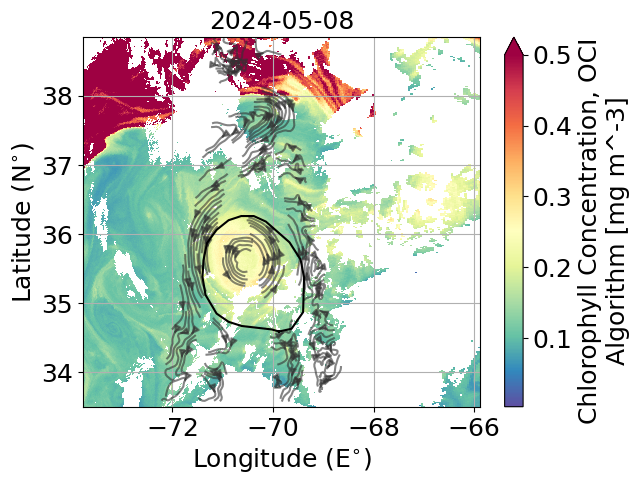

In [39]:
grid_x_180 = grid_x - 360 #only works for >180˚

fig = plt.figure()
ax = plt.axes()
plot=dataset["chlor_a"].plot(x="longitude", y="latitude", cmap="Spectral_r", vmax=0.5, ax=ax) #tried adding ,transform=ccrs.PlateCarree()
ax.grid(True)
ax.streamplot(grid_x_180,grid_y,ug1,vg1, density = 5, color = (0.2,0.2,0.2,0.6))
ax.streamplot(grid_x_180,grid_y,ug2,vg2, density = 5, color = (0.2,0.2,0.2,0.6))

ax.plot(contour_lons-360,contour_lats,zorder=100,c='k')
#ax.scatter(center_lon-360,center_lat)

ax.set_ylabel('Latitude (N$^{\circ}$)')
ax.set_xlabel('Longitude (E$^{\circ}$)')
ax.set_title('%s-%s-%s'%(date_requested[0:4],date_requested[4:6],date_requested[6:8]))

ax.set_ylim([latmin,latmax])
ax.set_xlim([lonmin,lonmax])

## Zoom out 

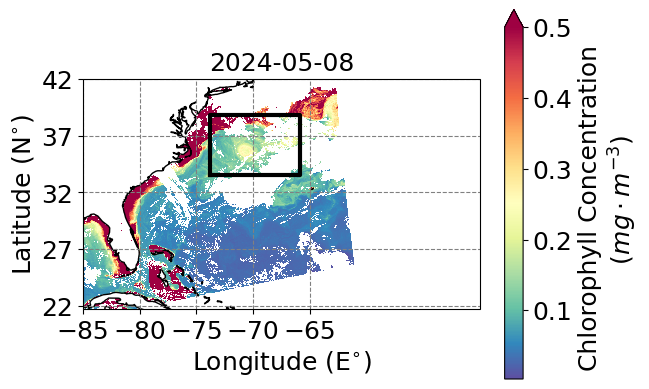

In [32]:
fig = plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
plot=dataset["chlor_a"].plot(x="longitude", y="latitude", cmap="Spectral_r", vmax=0.5, ax=ax) #tried adding ,transform=ccrs.PlateCarree()
plt.plot([lonmin,lonmax,lonmax,lonmin,lonmin],[latmin,latmin,latmax,latmax,latmin],c='k',lw=3,transform=ccrs.PlateCarree())
ax.grid(True)
ax.axis("scaled")
ax.set_ylabel('latitude')
ax.set_xlabel('longitude')
ax.set_ylim([21.7,42])
ax.set_xlim([-80,-50])

# Set gridlines with labels
ax.grid(True, linestyle='--', color='gray')

# Set latitude and longitude labels
ax.set_ylabel('Latitude (N$^{\circ}$)')
ax.set_xlabel('Longitude (E$^{\circ}$)')
ax.set_title('%s-%s-%s'%(date_requested[0:4],date_requested[4:6],date_requested[6:8]))

# Customize tick marks for latitude and longitude
ax.set_xticks(range(-85, -60, 5))  # Longitude ticks from -85 to -60 with a step of 5
ax.set_yticks(range(22, 43, 5))    # Latitude ticks from 22 to 42 with a step of 5

# Modify the colorbar
cbar = plot.colorbar
cbar.set_label('Chlorophyll Concentration \n ($mg\cdot m^{-3}$)')

/tmp/ipykernel_2329/2284987888.py:4: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plot=ax.pcolormesh(mlon,mlat,pro,cmap='YlGnBu_r',vmax=500000)


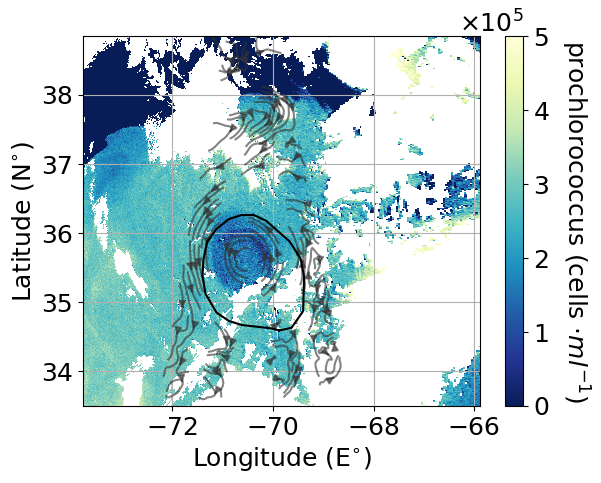

In [40]:
fig.clf()
fig = plt.figure()
ax = plt.axes()
plot=ax.pcolormesh(mlon,mlat,pro,cmap='YlGnBu_r',vmax=500000)
ax.streamplot(grid_x_180,grid_y,ug1,vg1, density = 3, color = (0.2,0.2,0.2,0.6))
ax.streamplot(grid_x_180,grid_y,ug2,vg2, density = 3, color = (0.2,0.2,0.2,0.6))

ax.plot(contour_lons-360,contour_lats,zorder=100,c='k')

ax.grid(True)
ax.set_ylim([latmin,latmax])
ax.set_xlim([lonmin,lonmax])
cbar = plt.colorbar(plot,ax=ax)
cbar.set_label('prochlorococcus (cells $ \cdot ml^{-1}$)', rotation=270, labelpad=30)
cbar.formatter.set_powerlimits((0, 0))
cbar.formatter.set_useMathText(True)

ax.set_ylabel('Latitude (N$^{\circ}$)')
ax.set_xlabel('Longitude (E$^{\circ}$)')
plt.show()

In [ ]:
fig.clf()
fig,ax=plt.subplots(3,1,figsize=(5,15))

# CHLA #
plot=ax[0].pcolormesh(dataset["longitude"],dataset["latitude"],dataset["chlor_a"],cmap='Spectral_r',vmax=0.35)
cbar = plt.colorbar(plot,ax=ax[0])
cbar.set_label('Chl-a (mg $ \cdot m^{-3}$)', rotation=270, labelpad=20)
ax[0].set_xticklabels([])

# Pro:Syn #
plot=ax[1].pcolormesh(mlon,mlat,np.divide(pro,syn),cmap='YlGnBu',vmax=1*(10**2))
cbar = plt.colorbar(plot,ax=ax[1])
cbar.set_label('Pro:Syn', rotation=270, labelpad=20)
cbar.formatter.set_powerlimits((0, 0))
cbar.formatter.set_useMathText(True)
ax[1].set_xticklabels([])

# Pro:Pico #
plot=ax[2].pcolormesh(mlon,mlat,np.divide(pro,pico),cmap='YlGnBu',vmax=1.5*(10**2))
cbar = plt.colorbar(plot,ax=ax[2])
cbar.set_label('Pro:Pico', rotation=270, labelpad=20)
cbar.formatter.set_powerlimits((0, 0))
cbar.formatter.set_useMathText(True)

for r in [0,1,2]:    
    ax[r].streamplot(grid_x_180,grid_y,ug1,vg1, density = 3, color = 'k',linewidth=1)
    ax[r].streamplot(grid_x_180,grid_y,ug2,vg2, density = 3, color = 'k',linewidth=1)
    ax[r].plot(contour_lons-360,contour_lats,zorder=100,c='k',linewidth=3)
    ax[r].set_ylim([latmin,latmax])
    ax[r].set_xlim([lonmin,lonmax])
    ax[r].grid(True)
    ax[r].set_facecolor('#e2e2e2')
    ax[r].set_ylabel('Latitude (N$^{\circ}$)')
    
    if r == 2:
        ax[r].set_xlabel('Longitude (E$^{\circ}$)')

# plt.savefig('chl_MOANA.png',dpi=350)

/tmp/ipykernel_2329/3162298727.py:5: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plot=ax[0].pcolormesh(dataset["longitude"],dataset["latitude"],dataset["chlor_a"],cmap='Spectral_r',vmax=0.35)
/tmp/ipykernel_2329/3162298727.py:11: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plot=ax[1].pcolormesh(mlon,mlat,np.divide(pro,syn),cmap='YlGnBu',vmax=1*(10**2))
/tmp/ipykernel_2329/3162298727.py:19: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in wh